# Project 2 — EfficientNet-B0 | Pakistani Politician Classification
**Category B** — No MLOps

## Step 1 — Google Drive Mount

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 2 — Libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import shutil

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


## Step 3 — Folder Names Fix (spaces → underscore, lowercase)

In [3]:
BASE_PATH = '/content/drive/MyDrive/dataset'

def fix_folder_names(base):
    for split in ['train', 'val', 'test']:
        split_path = os.path.join(base, split)
        if not os.path.exists(split_path):
            continue
        for folder in os.listdir(split_path):
            old_path = os.path.join(split_path, folder)
            if not os.path.isdir(old_path):
                continue
            # spaces ko underscore, sab lowercase
            new_name = folder.lower().replace(' ', '_')
            new_path = os.path.join(split_path, new_name)
            if old_path != new_path:
                os.rename(old_path, new_path)
                print(f'Renamed: {folder} -> {new_name}')
            else:
                print(f'OK: {folder}')

fix_folder_names(BASE_PATH)
print('\nFolder names fixed!')

OK: asif_ali_zardari
OK: imran_khan
OK: ishaq_dar
OK: chaudhary_nisar
OK: maryam_nawaz
OK: maulana_fazl-ur-rehman
OK: shahbaz_sharif
OK: ahmed_sharif_chaudhary
OK: assad_umar
OK: aitzaz_ahsan
OK: bilawal_bhutto_zardari
OK: shah_mehmood_quereshi
OK: khurshid_shah
OK: chaudhary_pervaiz_elahi
OK: rana_sanaullah
OK: nawaz_sharif
OK: asif_ali_zardari
OK: imran_khan
OK: chaudhary_nisar
OK: aitzaz_ahsan
OK: shahbaz_sharif
OK: ishaq_dar
OK: maulana_fazl-ur-rehman
OK: maryam_nawaz
OK: assad_umar
OK: ahmed_sharif_chaudhary
OK: khurshid_shah
OK: bilawal_bhutto_zardari
OK: shah_mehmood_quereshi
OK: rana_sanaullah
OK: chaudhary_pervaiz_elahi
OK: nawaz_sharif
OK: imran_khan
OK: asif_ali_zardari
OK: ishaq_dar
OK: maryam_nawaz
OK: shahbaz_sharif
OK: aitzaz_ahsan
OK: ahmed_sharif_chaudhary
OK: khurshid_shah
OK: maulana_fazl-ur-rehman
OK: shah_mehmood_quereshi
OK: bilawal_bhutto_zardari
OK: chaudhary_nisar
OK: rana_sanaullah
OK: assad_umar
OK: nawaz_sharif
OK: chaudhary_pervaiz_elahi

Folder names fixed

## Step 4 — Dataset Verify

In [4]:
TRAIN_DIR = os.path.join(BASE_PATH, 'train')
VAL_DIR   = os.path.join(BASE_PATH, 'val')
TEST_DIR  = os.path.join(BASE_PATH, 'test')

print(f'{"Split":8s} | {"Classes":>8} | {"Images":>8}')
print('-' * 30)
for split, d in [('train', TRAIN_DIR), ('val', VAL_DIR), ('test', TEST_DIR)]:
    count   = sum([len(files) for _, _, files in os.walk(d)])
    classes = len([f for f in os.listdir(d) if os.path.isdir(os.path.join(d, f))])
    print(f'{split:8s} | {classes:>8} | {count:>8}')

print('\nClass names:')
for c in sorted(os.listdir(TRAIN_DIR)):
    n = len(os.listdir(os.path.join(TRAIN_DIR, c)))
    print(f'  {c:35s} {n} images')

Split    |  Classes |   Images
------------------------------
train    |       16 |      993
val      |       16 |      200
test     |       16 |      138

Class names:
  ahmed_sharif_chaudhary              60 images
  aitzaz_ahsan                        60 images
  asif_ali_zardari                    64 images
  assad_umar                          60 images
  bilawal_bhutto_zardari              60 images
  chaudhary_nisar                     60 images
  chaudhary_pervaiz_elahi             60 images
  imran_khan                          79 images
  ishaq_dar                           60 images
  khurshid_shah                       60 images
  maryam_nawaz                        64 images
  maulana_fazl-ur-rehman              60 images
  nawaz_sharif                        63 images
  rana_sanaullah                      60 images
  shah_mehmood_quereshi               60 images
  shahbaz_sharif                      63 images


## Step 5 — Transforms & DataLoaders

In [17]:
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 50
NUM_CLASSES = 16

# Train augmentation — sirf training data pe
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.75, 1.0)),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Val/Test — sirf resize + normalize
val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=val_test_transform)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

class_names = train_dataset.classes
NUM_CLASSES = len(class_names)
print(f'Total classes: {NUM_CLASSES}')
print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Total classes: 16
Train: 993 | Val: 200 | Test: 138


## Step 6 — Sample Images Dekho

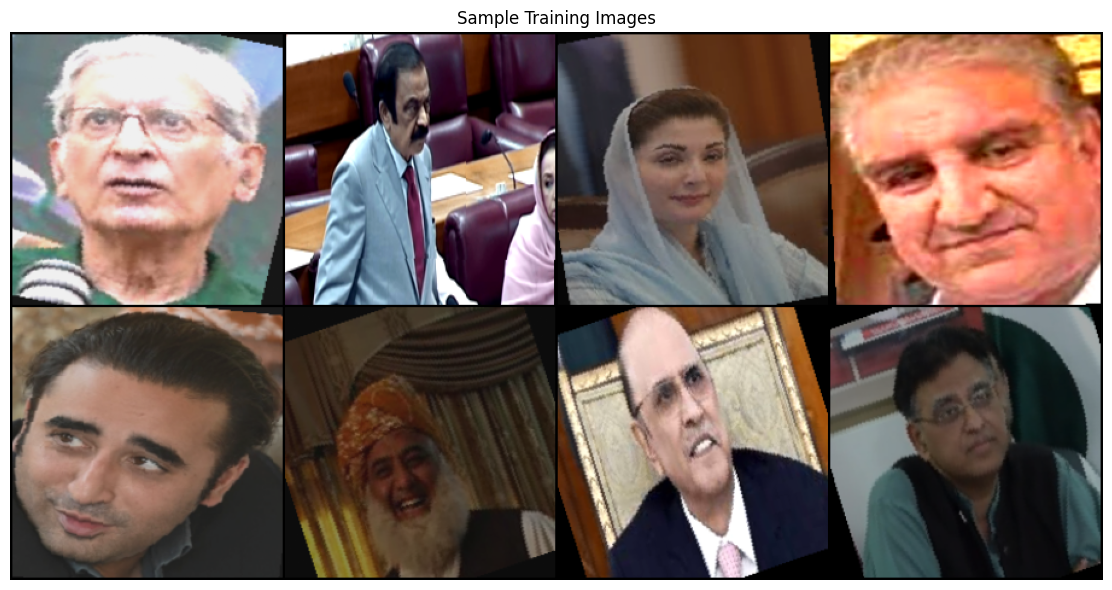

Labels: ['aitzaz_ahsan', 'rana_sanaullah', 'maryam_nawaz', 'shah_mehmood_quereshi', 'bilawal_bhutto_zardari', 'maulana_fazl-ur-rehman', 'asif_ali_zardari', 'assad_umar']


In [18]:
def imshow_grid(loader, class_names, n=8):
    images, labels = next(iter(loader))
    images = images[:n]
    labels = labels[:n]
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    images = torch.clamp(images * std + mean, 0, 1)
    grid = make_grid(images, nrow=4)
    plt.figure(figsize=(14, 6))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title('Sample Training Images')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
    print('Labels:', [class_names[l] for l in labels.tolist()])

imshow_grid(train_loader, class_names)

## Step 7 — Model Definitions

In [19]:
def get_efficientnet_b0(num_classes):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    # Last block unfreeze
    for param in model.features[-1].parameters():
        param.requires_grad = True
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return model

print('Models defined!')

Models defined!


## Step 8 — Training Function

In [20]:
def train_model(model, model_name, train_loader, val_loader,
                num_epochs=NUM_EPOCHS, lr=0.001):

    model     = model.to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=num_epochs, eta_min=1e-6
    )

    history = {'train_loss': [], 'train_acc': [],
               'val_loss':   [], 'val_acc':   []}

    best_val_acc = 0.0
    best_weights = None

    for epoch in range(num_epochs):
        # Train
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in tqdm(train_loader,
                                   desc=f'[{model_name}] Epoch {epoch+1}/{num_epochs}',
                                   leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds      = torch.max(outputs, 1)
            correct      += (preds == labels).sum().item()
            total        += labels.size(0)

        train_loss = running_loss / total
        train_acc  = correct / total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs        = model(images)
                loss           = criterion(outputs, labels)
                val_loss      += loss.item() * images.size(0)
                _, preds       = torch.max(outputs, 1)
                val_correct   += (preds == labels).sum().item()
                val_total     += labels.size(0)

        val_loss = val_loss / val_total
        val_acc  = val_correct / val_total
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        print(f'Epoch {epoch+1:02d} | '
              f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
              f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

    model.load_state_dict(best_weights)
    print(f'\nBest Val Accuracy [{model_name}]: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')
    return model, history

## Step 9 — EfficientNet-B0 Training

In [21]:
effnet_model = get_efficientnet_b0(NUM_CLASSES)
effnet_model, effnet_history = train_model(
    effnet_model, 'EfficientNet-B0',
    train_loader, val_loader,
    num_epochs=NUM_EPOCHS
)

Epoch 01 | Train Loss: 2.5350 Acc: 0.2608 | Val Loss: 2.0377 Acc: 0.5800


Epoch 02 | Train Loss: 1.7684 Acc: 0.5730 | Val Loss: 1.5376 Acc: 0.6450


Epoch 03 | Train Loss: 1.4698 Acc: 0.6777 | Val Loss: 1.3107 Acc: 0.7350


Epoch 04 | Train Loss: 1.3027 Acc: 0.7402 | Val Loss: 1.2262 Acc: 0.7850


Epoch 05 | Train Loss: 1.1985 Acc: 0.8006 | Val Loss: 1.1903 Acc: 0.8000


...

Epoch 46 | Train Loss: 0.7665 Acc: 0.9789 | Val Loss: 0.9780 Acc: 0.8650


Epoch 47 | Train Loss: 0.7626 Acc: 0.9708 | Val Loss: 0.9413 Acc: 0.9050


Epoch 48 | Train Loss: 0.7721 Acc: 0.9688 | Val Loss: 0.9604 Acc: 0.8800


Epoch 49 | Train Loss: 0.7748 Acc: 0.9648 | Val Loss: 0.9647 Acc: 0.8750


Epoch 50 | Train Loss: 0.7885 Acc: 0.9637 | Val Loss: 0.9503 Acc: 0.8750

Best Val Accuracy [EfficientNet-B0]: 0.9050 (90.50%)


## Step 10 — Fine Tuning

In [22]:
def finetune(model, model_name, train_loader, val_loader,
             num_epochs=10, lr=0.00003):
    print(f'Fine-tuning {model_name} with all layers...')
    for param in model.parameters():
        param.requires_grad = True
    model, history = train_model(
        model, f'{model_name}-Finetuned',
        train_loader, val_loader,
        num_epochs=num_epochs, lr=lr
    )
    return model, history

effnet_model, ft_history = finetune(effnet_model, 'EfficientNet-B0', train_loader, val_loader)

Fine-tuning EfficientNet-B0 with all layers...


Epoch 01 | Train Loss: 0.7782 Acc: 0.9597 | Val Loss: 0.9269 Acc: 0.8850


Epoch 02 | Train Loss: 0.7541 Acc: 0.9799 | Val Loss: 0.9121 Acc: 0.8850


Epoch 03 | Train Loss: 0.7555 Acc: 0.9829 | Val Loss: 0.8990 Acc: 0.9050


Epoch 04 | Train Loss: 0.7369 Acc: 0.9758 | Val Loss: 0.9095 Acc: 0.8950


...

Epoch 06 | Train Loss: 0.7333 Acc: 0.9859 | Val Loss: 0.8791 Acc: 0.9100


Epoch 07 | Train Loss: 0.7378 Acc: 0.9768 | Val Loss: 0.8962 Acc: 0.8950


Epoch 08 | Train Loss: 0.7334 Acc: 0.9819 | Val Loss: 0.9044 Acc: 0.8900


Epoch 09 | Train Loss: 0.7393 Acc: 0.9809 | Val Loss: 0.9023 Acc: 0.9050


Epoch 10 | Train Loss: 0.7391 Acc: 0.9778 | Val Loss: 0.8820 Acc: 0.9050

Best Val Accuracy [EfficientNet-B0-Finetuned]: 0.9150 (91.50%)


## Step 11 — Training Curves

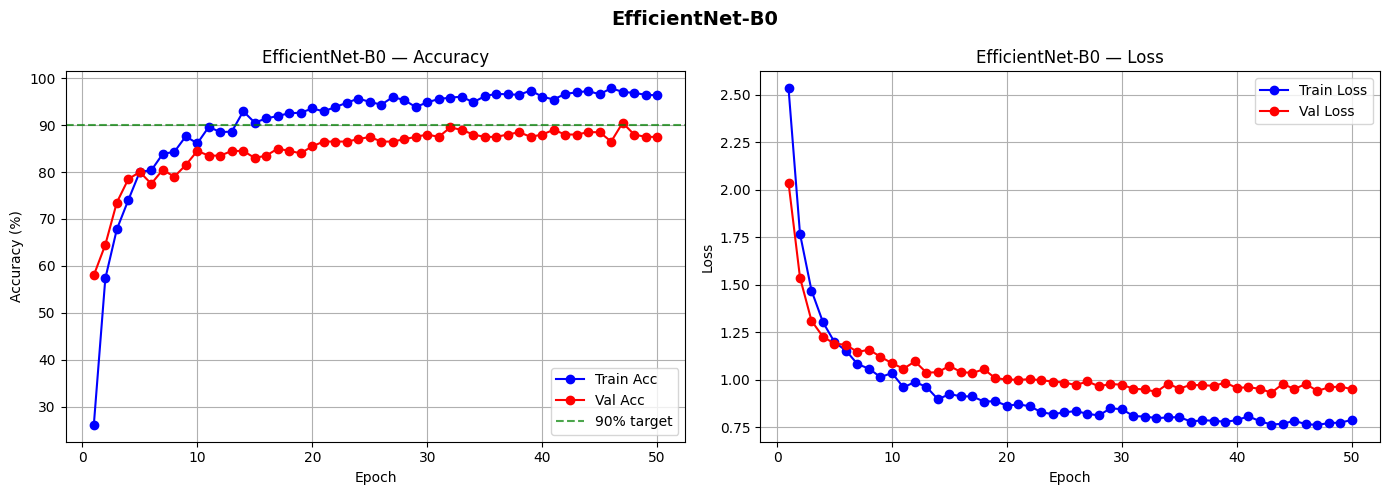

In [23]:
def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history['train_acc']) + 1)

    axes[0].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
    axes[0].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
    axes[0].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90% target')
    axes[0].set_title(f'{model_name} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy (%)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, history['train_loss'], 'b-o', label='Train Loss')
    axes[1].plot(epochs, history['val_loss'],   'r-o', label='Val Loss')
    axes[1].set_title(f'{model_name} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle(model_name, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(effnet_history, 'EfficientNet-B0')


## Step 12 — Test Evaluation

In [24]:
def evaluate_model(model, test_loader, class_names, model_name):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f'Testing {model_name}'):
            images   = images.to(device)
            outputs  = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='weighted')

    print(f'Test Results')
    print(f'Overall Accuracy : {acc*100:.2f}%')
    print(f'Weighted F1-Score: {f1:.4f}')
    print(f'\nPer-Class Report:')
    print(classification_report(
        all_labels, all_preds,
        target_names=class_names, digits=4
    ))
    return all_labels, all_preds, acc, f1
e_labels, e_preds, e_acc, e_f1 = evaluate_model(
    effnet_model, test_loader, class_names, 'EfficientNet-B0'
)


Testing EfficientNet-B0: 100%|██████████| 5/5 [00:01<00:00,  2.55it/s]

Test Results
Overall Accuracy : 86.96%
Weighted F1-Score: 0.8683

Per-Class Report:
                         precision    recall  f1-score   support

 ahmed_sharif_chaudhary     1.0000    1.0000    1.0000         9
           aitzaz_ahsan     0.8889    1.0000    0.9412         8
       asif_ali_zardari     0.7500    0.6667    0.7059         9
             assad_umar     0.8889    1.0000    0.9412         8
 bilawal_bhutto_zardari     1.0000    0.8750    0.9333         8
        chaudhary_nisar     1.0000    1.0000    1.0000         8
chaudhary_pervaiz_elahi     1.0000    0.7500    0.8571         8
             imran_khan     0.9000    0.8182    0.8571        11
              ishaq_dar     0.7273    0.8889    0.8000         9
          khurshid_shah     0.6667    0.5000    0.5714         8
           maryam_nawaz     0.9000    1.0000    0.9474         9
 maulana_fazl-ur-rehman     1.0000    1.0000    1.0000         8
           nawaz_sharif     0.8889    0.8889    0.8889         9
     

## Step 13 — Confusion Matrix

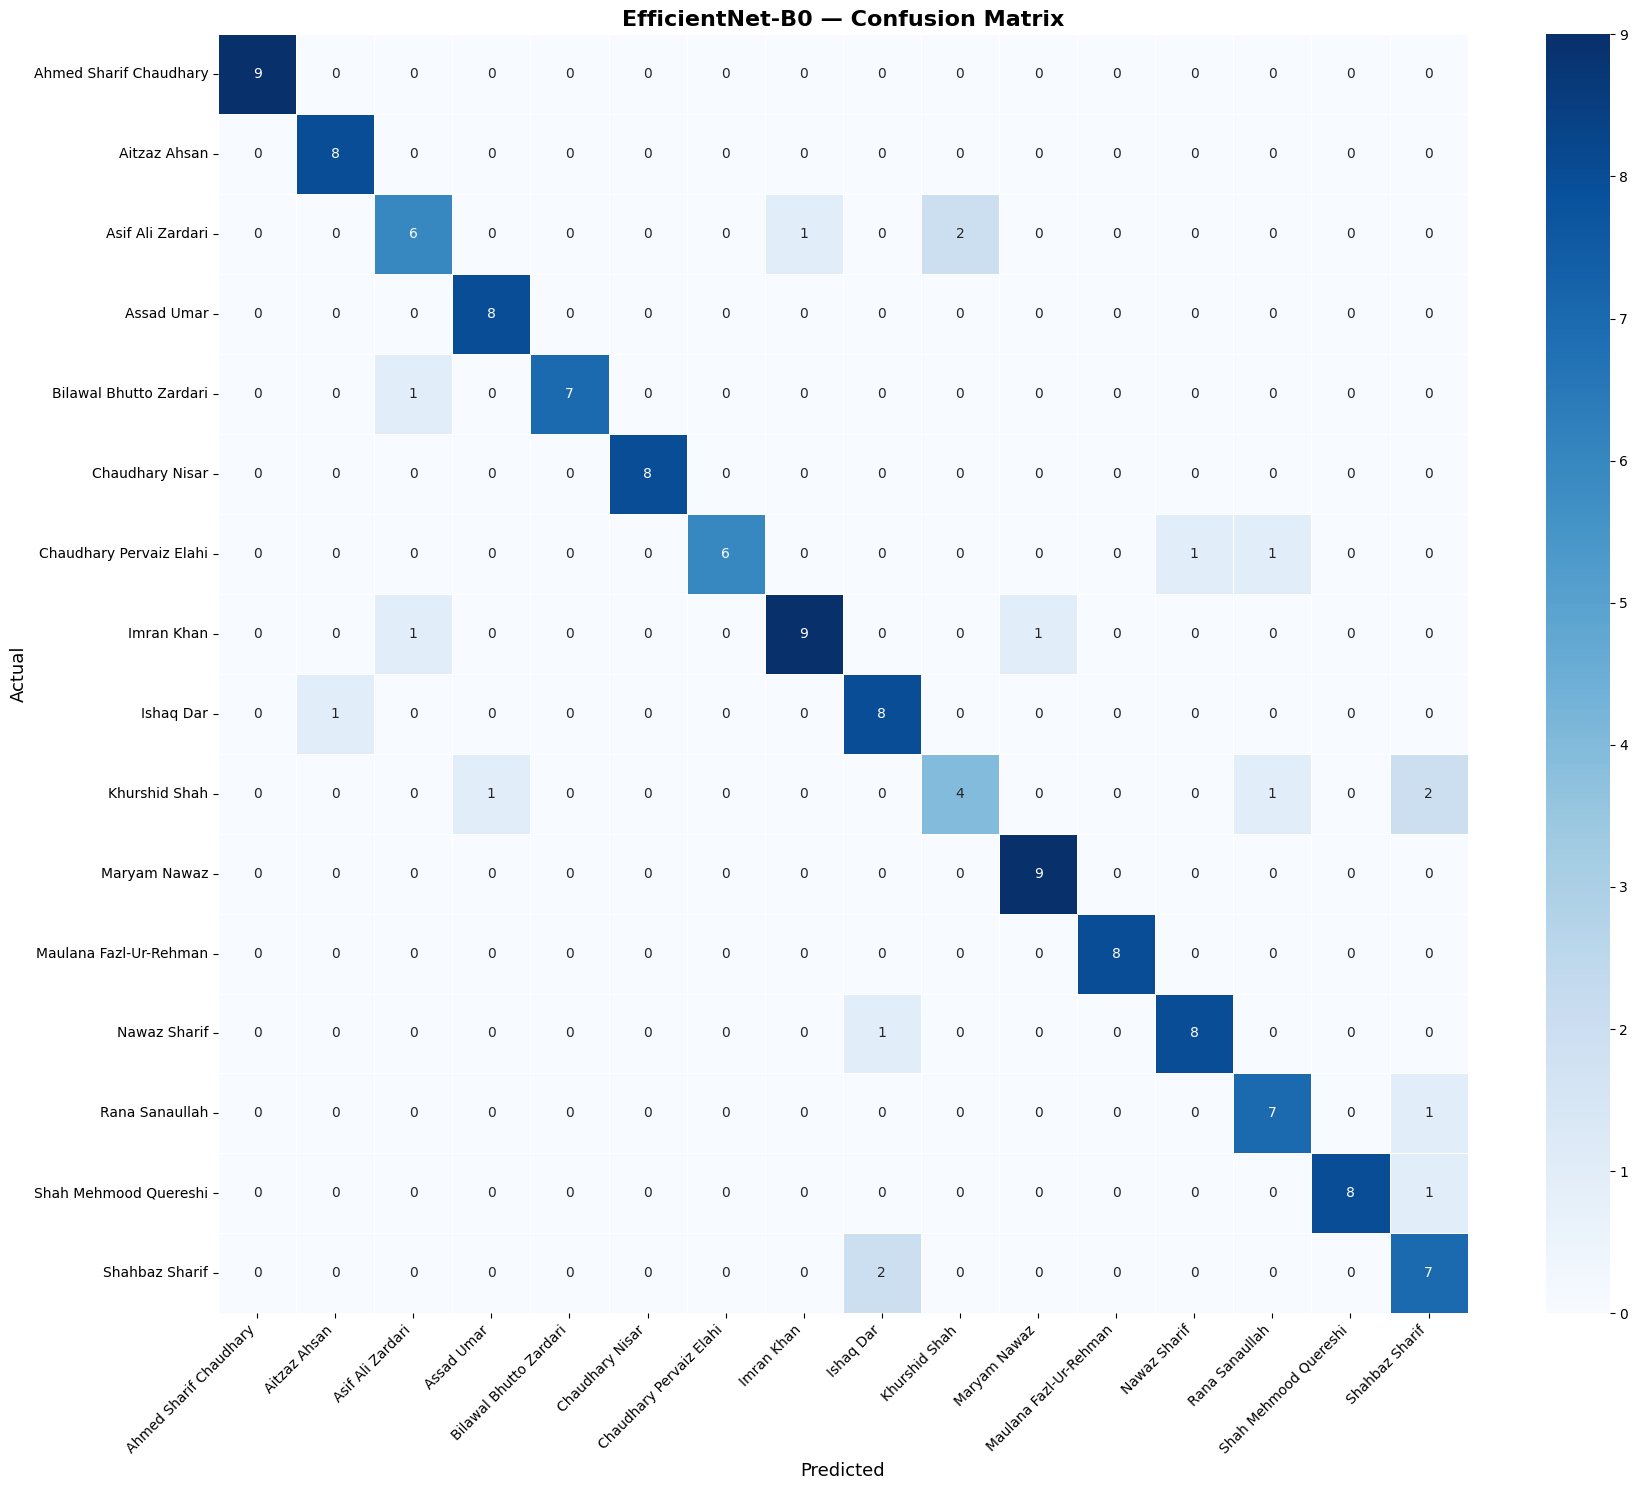

In [25]:
def plot_confusion_matrix(labels, preds, class_names, model_name):
    cm = confusion_matrix(labels, preds)
    pretty_names = [c.replace('_', ' ').title() for c in class_names]
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=pretty_names,
                yticklabels=pretty_names,
                linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix', fontsize=16, fontweight='bold')
    plt.ylabel('Actual', fontsize=13)
    plt.xlabel('Predicted', fontsize=13)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.yticks(rotation=0, fontsize=10)
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_confusion_matrix.png',
                dpi=150, bbox_inches='tight')
    plt.show()



plot_confusion_matrix(e_labels, e_preds, class_names, 'EfficientNet-B0')


## Step 14 — Top 5 Misclassified

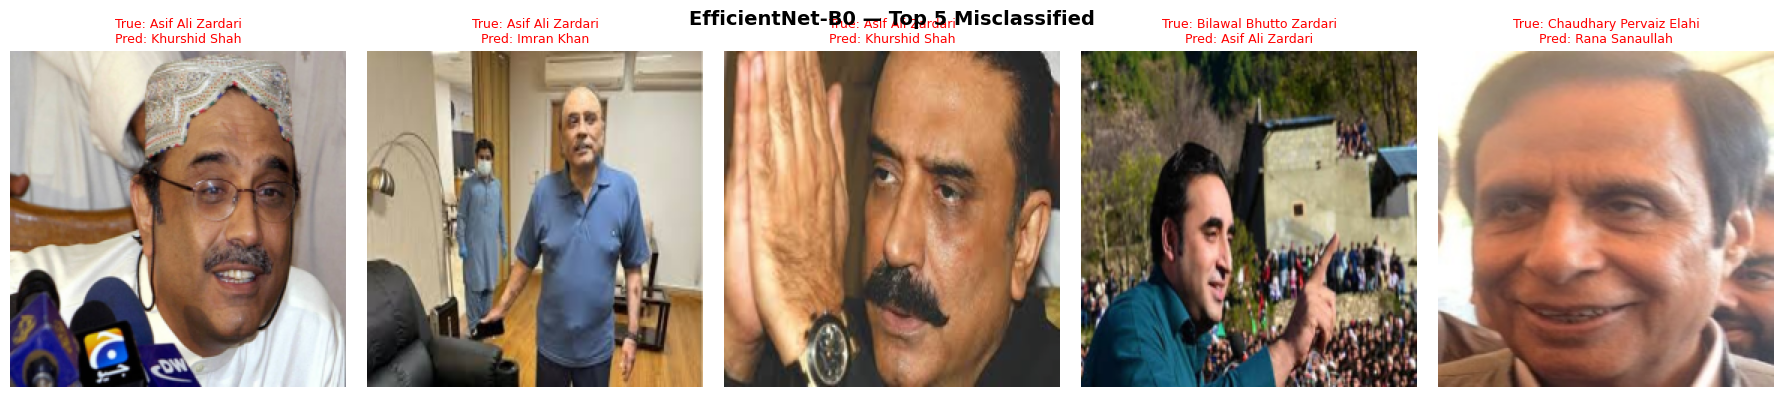

In [26]:
def show_misclassified(model, test_loader, class_names, model_name, top_n=5):
    model.eval()
    misclassified_imgs = []
    misclassified_true = []
    misclassified_pred = []

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs    = model(images_dev)
            _, preds   = torch.max(outputs, 1)
            preds_cpu  = preds.cpu()

            wrong_idx = (preds_cpu != labels).nonzero(as_tuple=True)[0]
            for idx in wrong_idx:
                if len(misclassified_imgs) >= top_n:
                    break
                img = torch.clamp(images[idx] * std + mean, 0, 1)
                misclassified_imgs.append(img)
                misclassified_true.append(labels[idx].item())
                misclassified_pred.append(preds_cpu[idx].item())
            if len(misclassified_imgs) >= top_n:
                break

    if len(misclassified_imgs) == 0:
        print(' 100% accuracy!')
        return

    fig, axes = plt.subplots(1, min(top_n, len(misclassified_imgs)), figsize=(18, 4))
    if top_n == 1:
        axes = [axes]
    fig.suptitle(f'{model_name} — Top {top_n} Misclassified', fontsize=14, fontweight='bold')
    for i in range(len(misclassified_imgs)):
        axes[i].imshow(misclassified_imgs[i].permute(1, 2, 0))
        true_name = class_names[misclassified_true[i]].replace('_',' ').title()
        pred_name = class_names[misclassified_pred[i]].replace('_',' ').title()
        axes[i].set_title(f'True: {true_name}\nPred: {pred_name}',
                          fontsize=9, color='red')
        axes[i].axis('off')
    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/{model_name}_misclassified.png',
                dpi=150, bbox_inches='tight')
    plt.show()



show_misclassified(effnet_model, test_loader, class_names, 'EfficientNet-B0')


In [29]:
save_path = '/content/drive/MyDrive/EfficientNet-B0-Finetuned.pth'

torch.save(effnet_model.state_dict(), save_path)

print(f"Model saved to Drive as: {save_path}")


Model saved to Drive as: /content/drive/MyDrive/EfficientNet-B0-Finetuned.pth
